# Tarea Análisis Exploratorio de Datos

**Autor:** Gil Brandon Garcia Contreras
**Fecha:** 16 de febrero de 2026

## Objetivo

Esta tarea busca que experimenten directamente con el proceso de análisis exploratorio de datos (EDA). A diferencia de otros temas del curso donde aprenderán algoritmos específicos con pasos definidos, el EDA es fundamentalmente una actividad artesanal y creativa. No existe una receta única: cada dataset cuenta una historia diferente, y su trabajo es descubrir cuál es esa historia mediante preguntas inteligentes y visualizaciones apropiadas.

## Introducción

El Titanic fue una embarcación creada en el siglo XX, la cual causó sensación debido a que era el barco de pasajeros más grande que se había hecho hasta el momento. Este zarpó de Inglaterra con rumbo a Nueva York, donde sufrió una de las tragedias más significativas del siglo pasado. En 1912, en su viaje inaugural, el Titanic sufrió una colisión con un iceberg, lo cual ocasionó su hundimiento, dejando consigo una gran cantidad de víctimas e incontables historias de vida. 

La intención de analizarlo nace de la gran cantidad de información que nos da el conjunto de datos sobre cómo actúan las masas en situaciones de riesgo. Nos proporciona información sobre patrones sociales, económicos y políticos. También nos permite descubrir historias extraordinarias de supervivencia y tragedias importantes que recordar. Es fundamental siempre tomar las estadísticas de fallecidos con extremo cuidado, ya que detrás de cada fila hay una vida con una historia detrás.

Es por esto que me adentro en este conjunto de datos con la intención de, además de encontrar patrones, encontrar historias extraordinarias sobre supervivencia y decisiones sociales. También considero que me ayudará a practicar mi análisis de datos y me gustaría que los patrones que encuentre sean algunos que no pueda predecir únicamente con lógica, cosas que me sorprendan más allá de lo que mi mente puede predecir. Dicho eso, mis predicciones para el conjunto son: existe una mayor supervivencia de los pasajeros de mayor clase, el fenómeno "mujeres y niños primero" está presente y la gran mayoría de adultos mayores no sobrevivió. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno 

# Cargar datos
titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1 # Creación de variable de tamaño de familia

In [2]:
titanic.head() # Primeras filas

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [3]:
titanic.describe() #Describe los datos

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [4]:
titanic.info() #Muestra los tipos de variables y la cantidad de valores nulos

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), str(5)
memory usage: 90.6 KB


## Parte 1: Variación (¿Cómo varían mis datos?)

Preguntas a analizar:

- Survived: ¿Cuanto porcentaje de gente sobrevivio?
- Pclass: ¿Cuánta gente había de cada clase?
- Fare: ¿Como se distribuyen la tarifa?
- Age: ¿Como se distribuye la edad?
- FamilySize: ¿Cuanta gente viajaba en familia?

In [5]:
survived = titanic['Survived'].value_counts() #Contamos los valores de supervivencia

print(survived, (survived / len(titanic) * 100).round(2)) #Hacemos display de los valores y sus porcentajes del total

Survived
0    549
1    342
Name: count, dtype: int64 Survived
0    61.62
1    38.38
Name: count, dtype: float64


In [6]:
pcclass = titanic['Pclass'].value_counts()

print(pcclass, (pcclass / len(titanic) * 100).round(2))

Pclass
3    491
1    216
2    184
Name: count, dtype: int64 Pclass
3    55.11
1    24.24
2    20.65
Name: count, dtype: float64


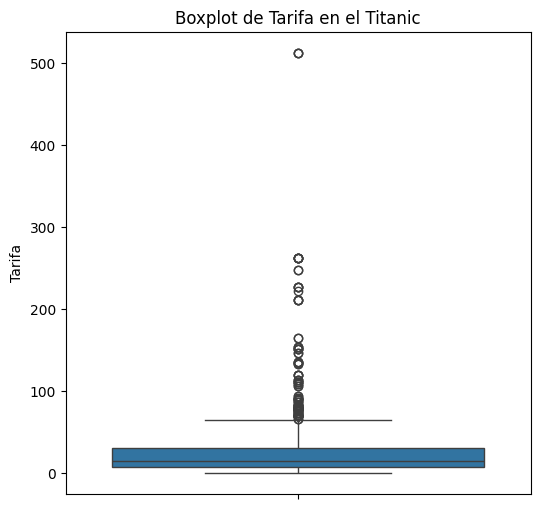

     PassengerId  Survived  Pclass                                Name  \
258          259         1       1                    Ward, Miss. Anna   
679          680         1       1  Cardeza, Mr. Thomas Drake Martinez   
737          738         1       1              Lesurer, Mr. Gustave J   

        Sex   Age  SibSp  Parch    Ticket      Fare        Cabin Embarked  \
258  female  35.0      0      0  PC 17755  512.3292          NaN        C   
679    male  36.0      0      1  PC 17755  512.3292  B51 B53 B55        C   
737    male  35.0      0      0  PC 17755  512.3292         B101        C   

     FamilySize  
258           1  
679           2  
737           1  


In [7]:
plt.figure(figsize=(6, 6)) #Creamos figura
sns.boxplot(data=titanic, y='Fare') #Definimos el tipo de grafico a boxplot y los datos a utilizar
plt.ylabel('Tarifa') 
plt.title('Boxplot de Tarifa en el Titanic')
plt.show() #Mostramos la figura

mayores_300 = titanic.query('Fare > 300') #Buscamos los datos atipocs
print(mayores_300) #Mostramos los datos atipicos

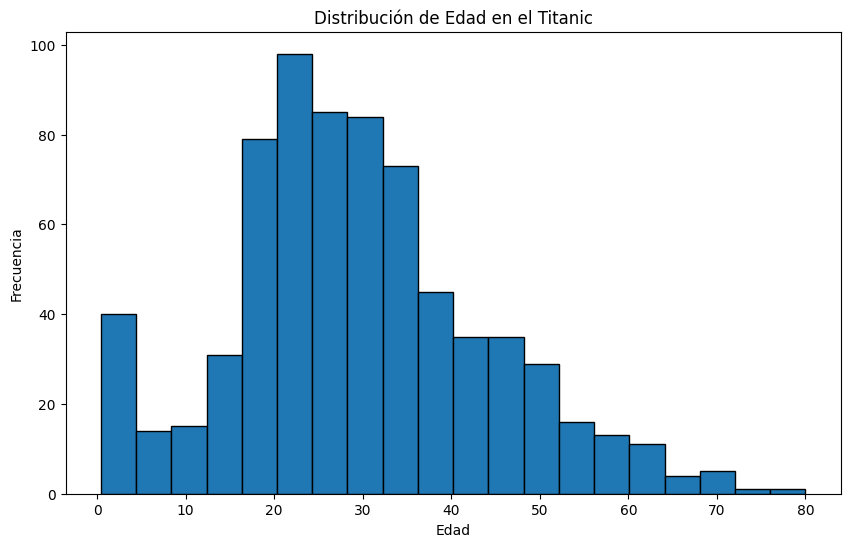

22 2.4691358024691357
113 12.682379349046016


In [8]:
plt.figure(figsize=(10, 6))
plt.hist(titanic['Age'].dropna(), bins=20, edgecolor='black') # Definimos la grafico a un histograma con adiciones esteticas y quitando los valores nulos 
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edad en el Titanic')
plt.show()
mayores_60 = titanic.query('Age > 60')
menores_18 = titanic.query('Age < 18')

print(len(mayores_60), len(mayores_60) / len(titanic) * 100)
print(len(menores_18), len(menores_18) / len(titanic) * 100)

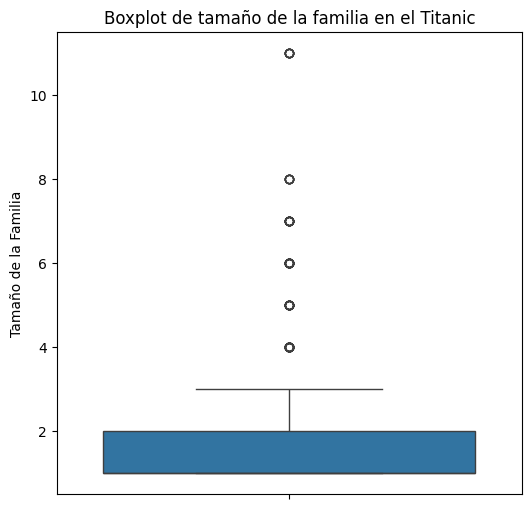

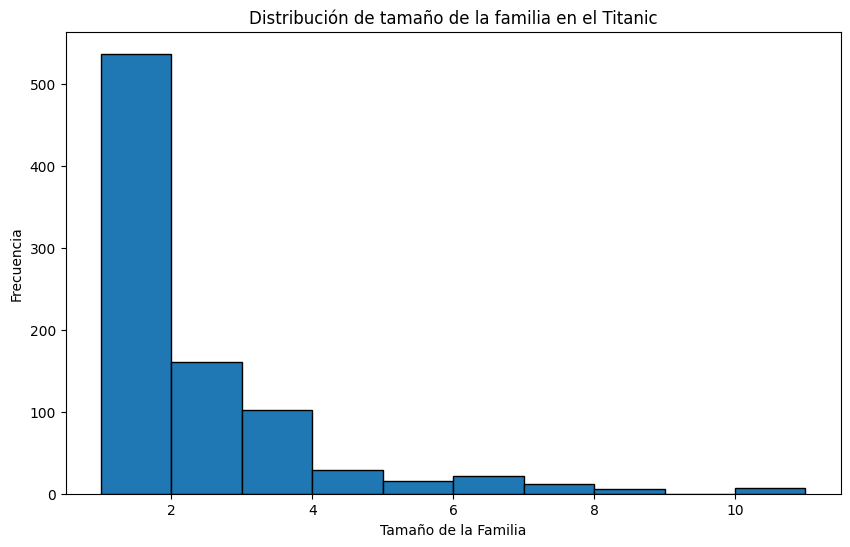

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64 FamilySize
1     60.27
2     18.07
3     11.45
4      3.25
6      2.47
5      1.68
7      1.35
11     0.79
8      0.67
Name: count, dtype: float64      PassengerId  Survived  Pclass                               Name     Sex  \
159          160         0       3         Sage, Master. Thomas Henry    male   
180          181         0       3       Sage, Miss. Constance Gladys  female   
201          202         0       3                Sage, Mr. Frederick    male   
324          325         0       3           Sage, Mr. George John Jr    male   
792          793         0       3            Sage, Miss. Stella Anna  female   
846          847         0       3           Sage, Mr. Douglas Bullen    male   
863          864         0       3  Sage, Miss. Dorothy Edith "Dolly"  female   

     Age  SibSp  Parch    Ticket   Fare Cabin Embarked  FamilySize  
159  NaN

In [9]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=titanic, y='FamilySize')
plt.ylabel('Tamaño de la Familia')
plt.title('Boxplot de tamaño de la familia en el Titanic')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(titanic['FamilySize'].dropna(), edgecolor='black')
plt.xlabel('Tamaño de la Familia')
plt.ylabel('Frecuencia')
plt.title('Distribución de tamaño de la familia en el Titanic')
plt.show()

family = titanic['FamilySize'].value_counts()
family_11 = titanic.query('FamilySize >= 11')

print(family, (family / len(titanic) * 100).round(2), family_11)

Tras analizar las 5 variables que me parecían más interesantes, encontré varios detalles curiosos. El porcentaje de sobrevivencia fue del 38 %, el cual me parece alto para la tragedia que fue en su momento. Uno pensaría que la supervivencia estaría por los suelos, aunque, comparándola con los números actuales de supervivencia a catástrofes, claramente se puede ver la diferencia de tecnología entre ambas épocas. 

Por otra parte, analizando las clases de pasajeros, me pareció curioso que la suma porcentual de la segunda y primera clase fuera menor que la enteridad de la tercera. También me sorprendió el hecho de que hubiera más participantes de primera clase que de segunda, algo que denota el fenómeno social que fue el barco en su momento. 

En el apartado de tarifa de boletos se puede notar que existe un punto bastante alejado del resto, alrededor de los 500 dólares. Revisando por todas las personas que pagaron más de 300 dólares, podemos ver que únicamente se encuentran 3 en esta categoría. Haciendo una investigación más profunda, podemos ver que el pasajero principal fue Thomas Drake Martínez Cardeza, el cual llevaba a su madre y un sirviente personal. Él era el único que utilizó una de las dos suites principales dentro del Titanic y la razón principal por la que la media de la tarifa es tan alta. Cabe recalcar que los 3 sobrevivieron. 

Siguiendo con la edad, podemos ver que la mayoría de los pasajeros estaban en un rango de entre 20 y 40 años. Unicamente 26 mayores y 113 menores de edad abordaban el barco, un 2.46 % y 12.7 % respectivamente.

Finalmente, la última variable que analicé fue el tamaño de las familias, una variable creada por mí. En esta se puede observar cómo la mayoría de las personas viajaban sin familiares. Sin embargo, podemos notar un valor atípico de una familia con 11 miembros de tercera clase, los Sage, de los cuales ninguno sobrevivió y se desconocen sus edades. 

## Parte 2: Covariación (¿Cómo se relacionan las variables?)

Preguntas clave:

- Pclass y Survived: ¿Como se relaciona la clase de los pasajeros con su supervivencia?
- Fare y Survived: ¿Las personas que pagaron más tenian más prbabilidad de sobrevivir?
- Sex y Survived: ¿Cual fue la diferencia de superviviencia con respecto al genero?
- Age y Survived: ¿Los menores de edad tenian una mayor probabilidad de supervivencia?
- FamilySize y Survived: ¿El numero de la familia influye en la supervivivencia?


        Survived       Fare                           Age FamilySize    
            mean       mean   median       max       mean       mean max
Pclass                                                                  
1       0.629630  84.154687  60.2875  512.3292  38.233441   1.773148   6
2       0.472826  20.662183  14.2500   73.5000  29.877630   1.782609   6
3       0.242363  13.675550   8.0500   69.5500  25.140620   2.008147  11


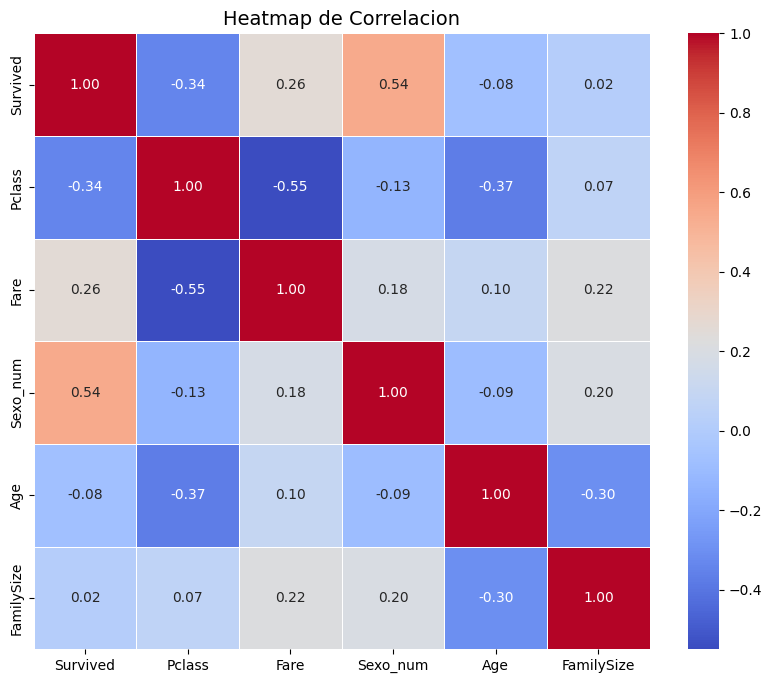

In [10]:
clase = titanic.groupby('Pclass').agg({
    'Survived': 'mean',
    'Fare': ['mean', 'median', 'max'],
    'Age' : ['mean'], 
    'FamilySize' : ['mean', 'max']
}) #Creamos un subset con información relevante de las variables a analizar con respceto a la clase

print(clase)

titanic['Sexo_num'] = titanic['Sex'].map({'male': 0, 'female': 1}) #Creamos una versión numerica de la variable Sex para su correlación numerica

variables_interes = titanic[['Survived', 'Pclass', 'Fare', 'Sexo_num', 'Age', 'FamilySize']] #Creamos un subset con unicamente las variables de interes numericas
corr = variables_interes.corr() #Creamos la matrix de correlación

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths= 0.5) #Hacemos un mapa de calor para mejor display
plt.title('Heatmap de Correlacion', fontsize=14)
plt.show()



<Figure size 1000x800 with 0 Axes>

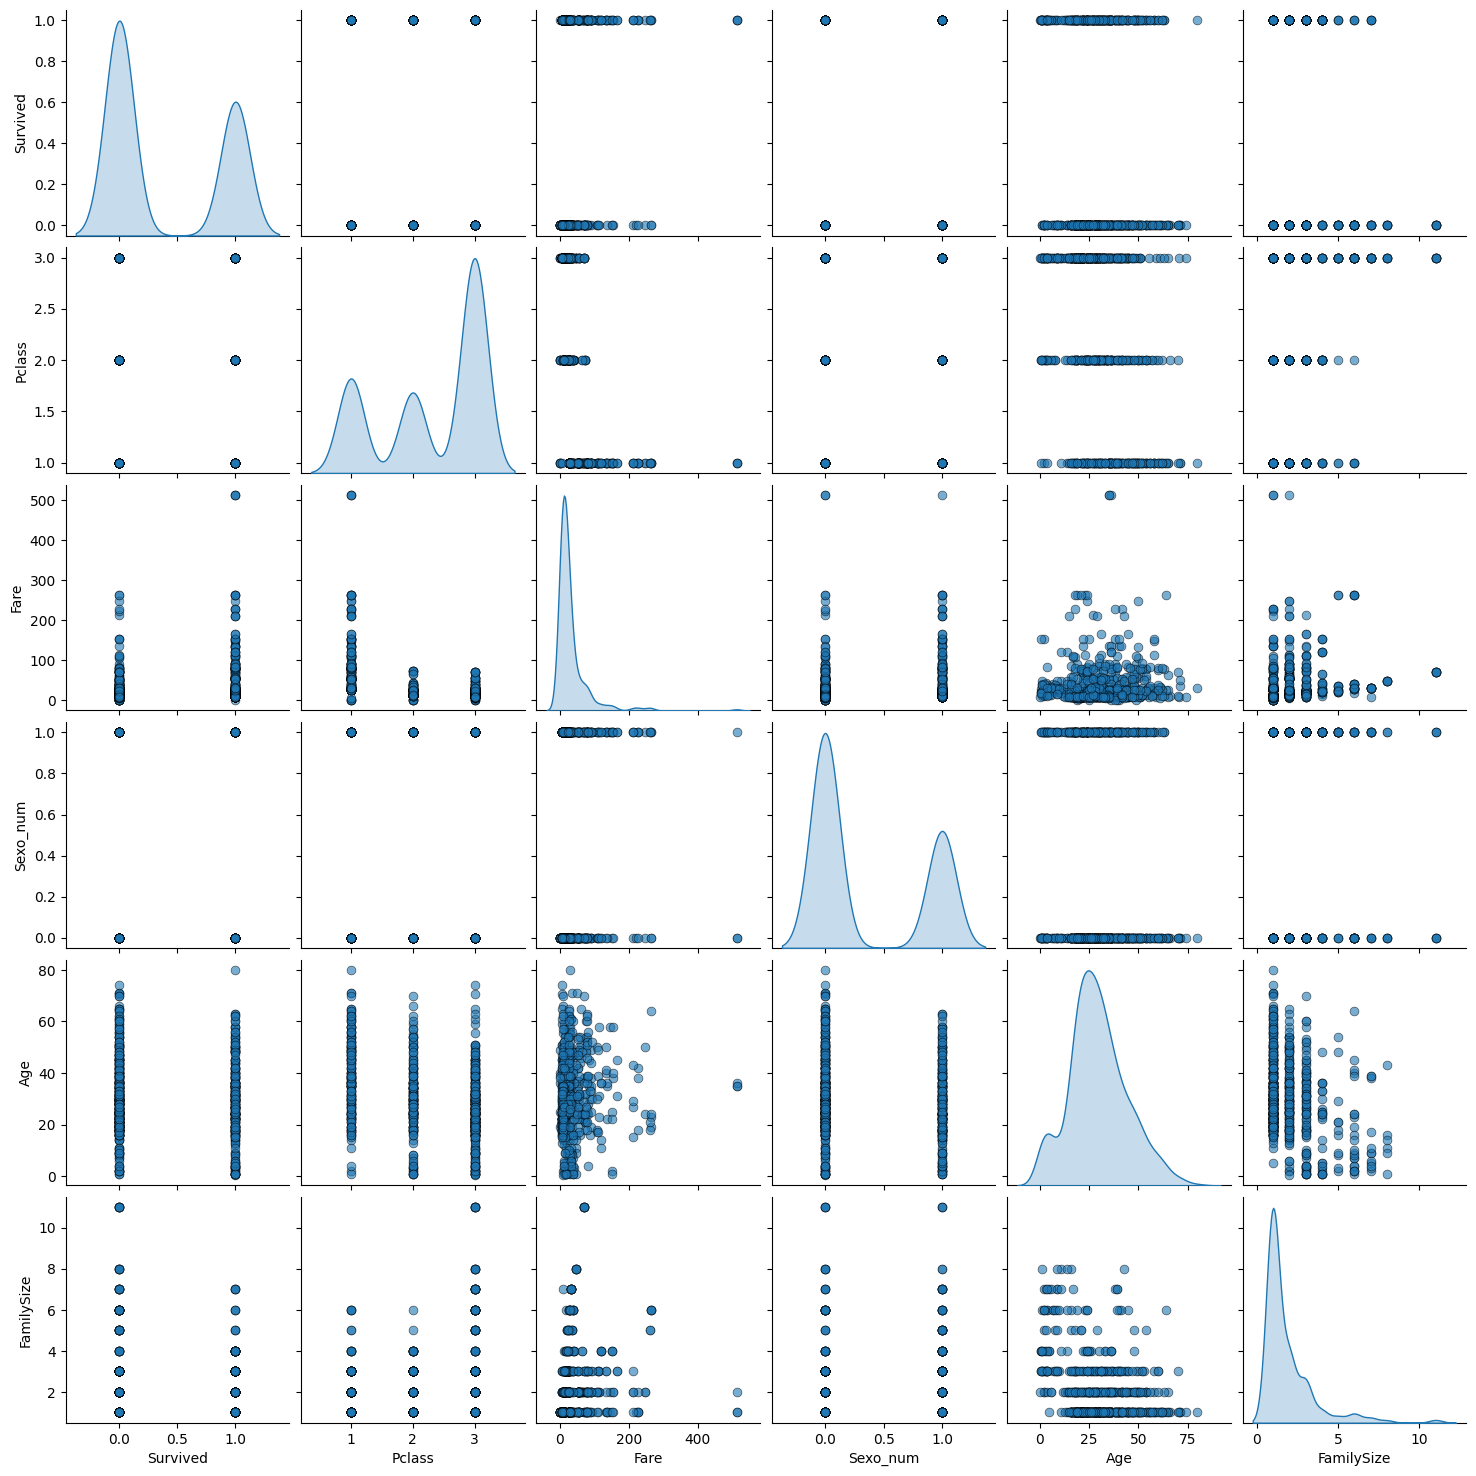

In [11]:
plt.figure(figsize=(10, 8))
sns.pairplot(variables_interes, diag_kind='kde', plot_kws={'alpha': 0.6, 's':40, 'edgecolor':'k'}) #Displa de matrix de graficos de dispersión
plt.show()

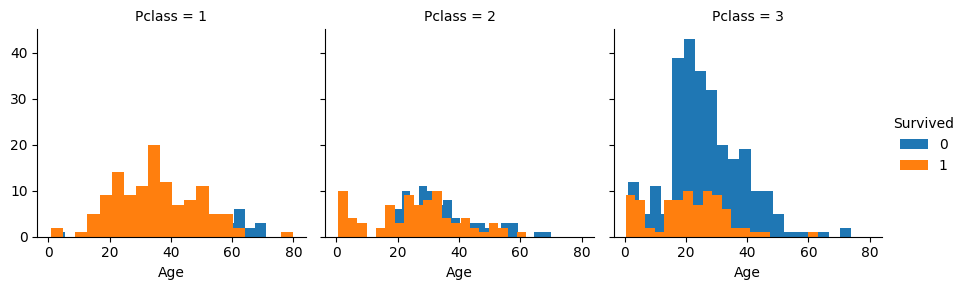

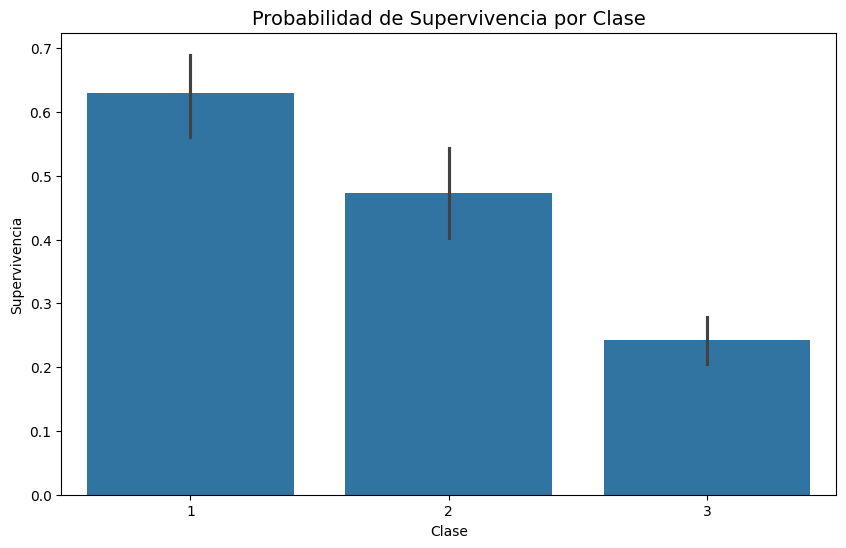

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


In [12]:
g = sns.FacetGrid(titanic, col='Pclass', hue='Survived')
g.map(plt.hist, 'Age', bins=20)
g.add_legend()

plt.figure(figsize=(10, 6))
sns.barplot(data=titanic, x='Pclass', y='Survived') #Creamos un grafico de barras
plt.title('Probabilidad de Supervivencia por Clase', fontsize=14)
plt.ylabel('Supervivencia')
plt.xlabel('Clase')
plt.show()

clase_supervivencia = titanic.groupby('Pclass')['Survived'].mean()
print((clase_supervivencia * 100).round(2))

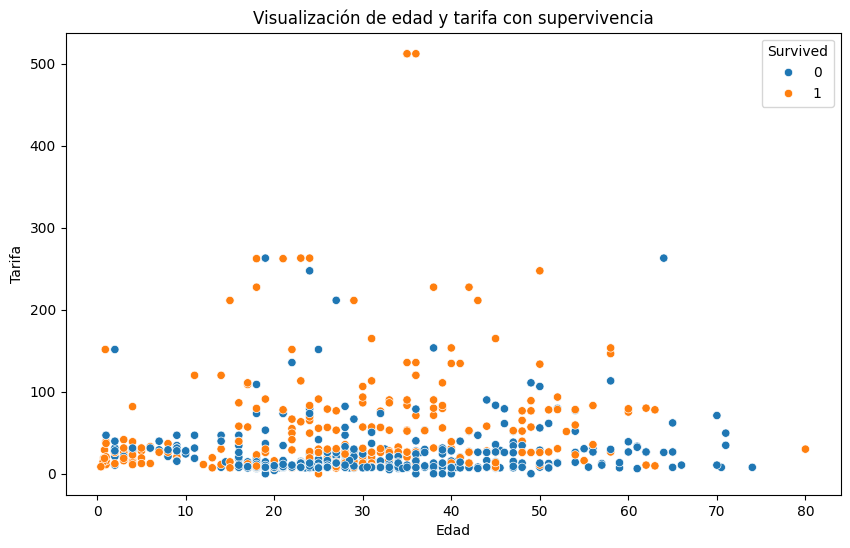

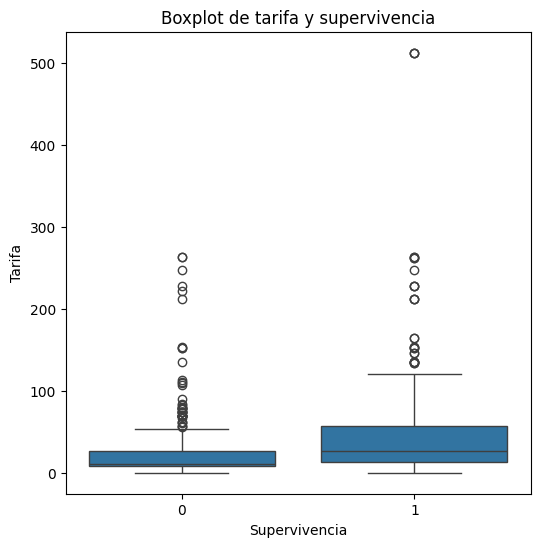

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=titanic, x='Age', y='Fare', hue='Survived') #Creamos un grafico de dispersión
plt.ylabel('Tarifa')
plt.xlabel('Edad')
plt.title('Visualización de edad y tarifa con supervivencia')
plt.show()

plt.figure(figsize=(6, 6))
sns.boxplot(data=titanic, x='Survived', y='Fare')
plt.ylabel('Tarifa')
plt.xlabel('Supervivencia')
plt.title('Boxplot de tarifa y supervivencia')
plt.show()

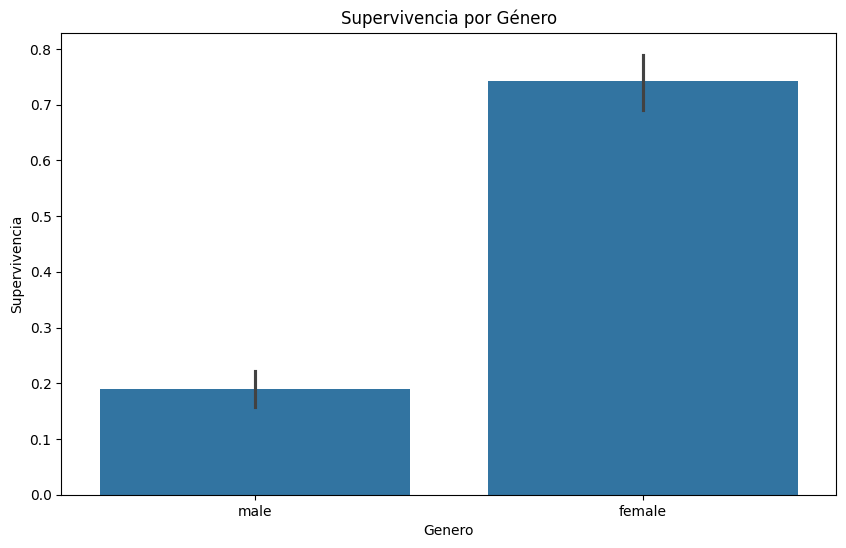

Porcentaje de hombres y mujeres
Sex
male      64.76
female    35.24
Name: count, dtype: float64
Supervivencia Porcentual
Survived      0      1
Sex                   
female     9.09  26.15
male      52.53  12.23


In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(data=titanic, x='Sex', y='Survived')
plt.ylabel('Supervivencia')
plt.xlabel('Genero')
plt.title('Supervivencia por Género')
plt.show()

sexo = titanic['Sex'].value_counts()

print("Porcentaje de hombres y mujeres")
print((sexo / len(titanic) * 100).round(2))

print("Supervivencia Porcentual")
sex_supervivencia = pd.crosstab(titanic['Sex'], titanic['Survived']) #Mostrar la relación entre sexo y superviviencia
print((sex_supervivencia / len(titanic) * 100).round(2))

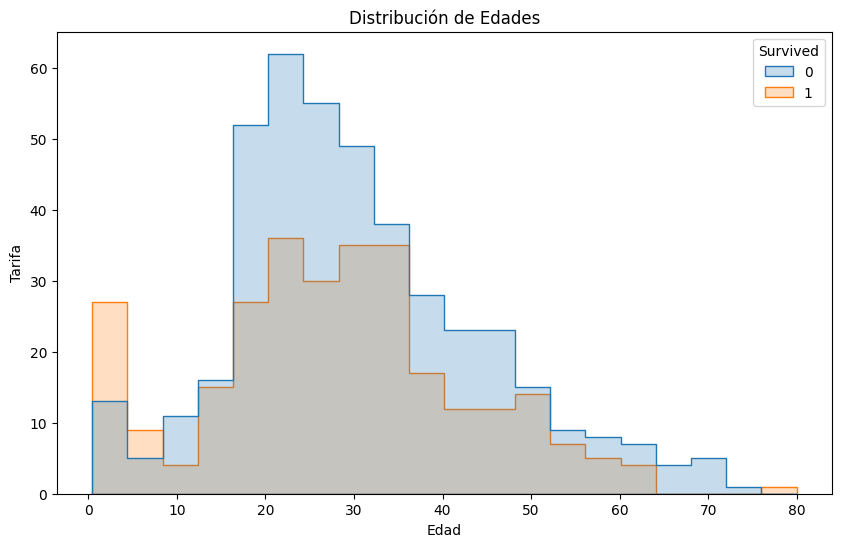

AgeStage
Niño           57.97
Adolescente    38.18
Juventud       36.52
Adulto         42.05
Anciano        22.73
Name: Survived, dtype: float64
Survived
0    77.27
1    22.73
Name: count, dtype: float64
Survived
1    53.98
0    46.02
Name: count, dtype: float64


In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(data=titanic, x='Age', hue='Survived', element="step")
plt.title('Distribución de Edades')
plt.ylabel('Tarifa')
plt.xlabel('Edad')
plt.show()

titanic['AgeStage'] = pd.cut(titanic['Age'], bins=[0, 12, 20, 30, 60, 100], labels=['Niño', 'Adolescente', 'Juventud', 'Adulto', 'Anciano']) #Creamos variable AgeStage para lidiar con las edades de mejor manera
supervivencia_edad = titanic.groupby('AgeStage')['Survived'].mean()
print((supervivencia_edad * 100).round(2))

print((mayores_60['Survived'].value_counts() / len(mayores_60) * 100).round(2))
print((menores_18['Survived'].value_counts() / len(menores_18) * 100).round(2))

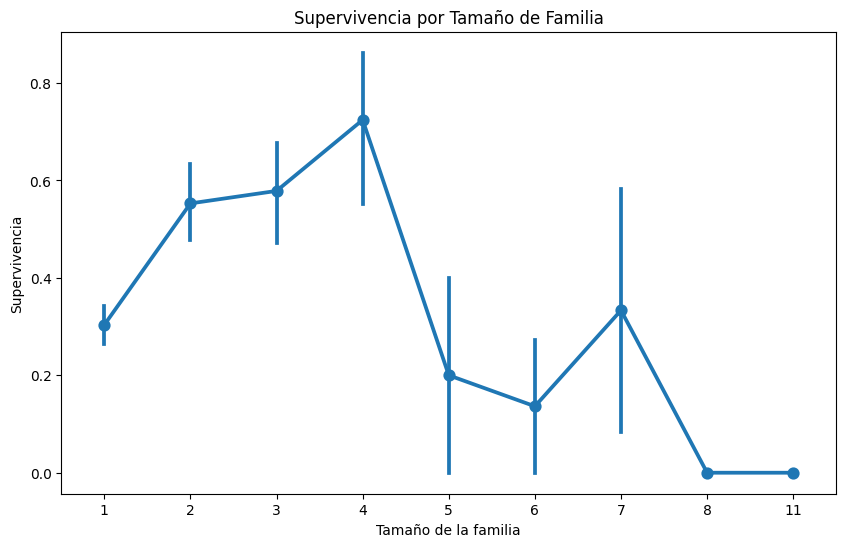

            Survived
FamilySize          
1              30.35
2              55.28
3              57.84
4              72.41
5              20.00
6              13.64
7              33.33
8               0.00
11              0.00


In [16]:
plt.figure(figsize=(10, 6))
sns.pointplot(data=titanic, x='FamilySize', y='Survived') #Creamos un poinplot
plt.title('Supervivencia por Tamaño de Familia')
plt.ylabel('Supervivencia')
plt.xlabel('Tamaño de la familia')
plt.show()

familia_supervivencia = titanic.pivot_table(index='FamilySize', values='Survived') 
print((familia_supervivencia*100).round(2))

Analizando la matriz de covarianza, podemos notar que las variables más correlacionadas son la supervivencia con el sexo y la tarifa con la clase. La segunda de estas es predecible, pero la primera nos da un indicio de las respuestas a una de las preguntas planteadas al inicio. Adentrándonos más en esta correlación, podemos ver que, aunque las mujeres constituían únicamente el 35 % del total de pasajeros en el barco, el 26 % del total de pasajeros fueron supervivientes mujeres. Comparado con el 38 % (total de supervivientes), vemos que el porcentaje de mujeres supera por más del doble al de los hombres, aun cuando estos eran la mayoría. Probando que el ser del género femenino jugaba un fuerte rol en la supervivencia a la tragedia. 

Otras variables que demostraron jugar un gran papel en la supervivencia fueron la clase y la edad. Esto lo podemos notar dado que el 62 % de los pasajeros de primera clase fueron capaces de sobrevivir, el cual es un porcentaje muy superior al de todas las demás clases. Además, si consideramos que los pasajeros de primera clase únicamente constituyen el 20 % del total de pasajeros, podemos ver aún más la proporción desmedida. 

Por otra parte, se puede ver cómo la edad también jugaba un rol relevante. Esto se puede observar comparando los dos extremos de edades: de los pasajeros de tercera clase, únicamente el 22 % sobrevivió, mientras que el 46 % de los menores de edad fueron capaces de sobrevivir. Este porcentaje aumenta conforme reducimos la edad, ya que si consideramos únicamente a los menores de 12, el 57 % sobrevivió, el porcentaje más alto de todos los grupos de edad. Esto nos indica que se priorizó el abordaje de los niños en primera instancia. 

Finalmente, analizando el tamaño de la familia, podemos encontrar que el número ideal para sobrevivir era tener una familia de 4 integrantes. Posterior a este número, la supervivencia se desploma hasta llegar a los 8 miembros en adelante, donde nadie logró sobrevivir. Esto nos da un indicio de que existió un fenómeno de permitir a las personas abordar con sus familiares cercanos, aunque se requeriría de más información para poder asegurarlo. 

## Parte 3: Valores Faltantes

In [17]:
titanic.isnull().sum() #Mostramos la suma de todos los valores nulos

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
Sexo_num         0
AgeStage       177
dtype: int64

<Axes: >

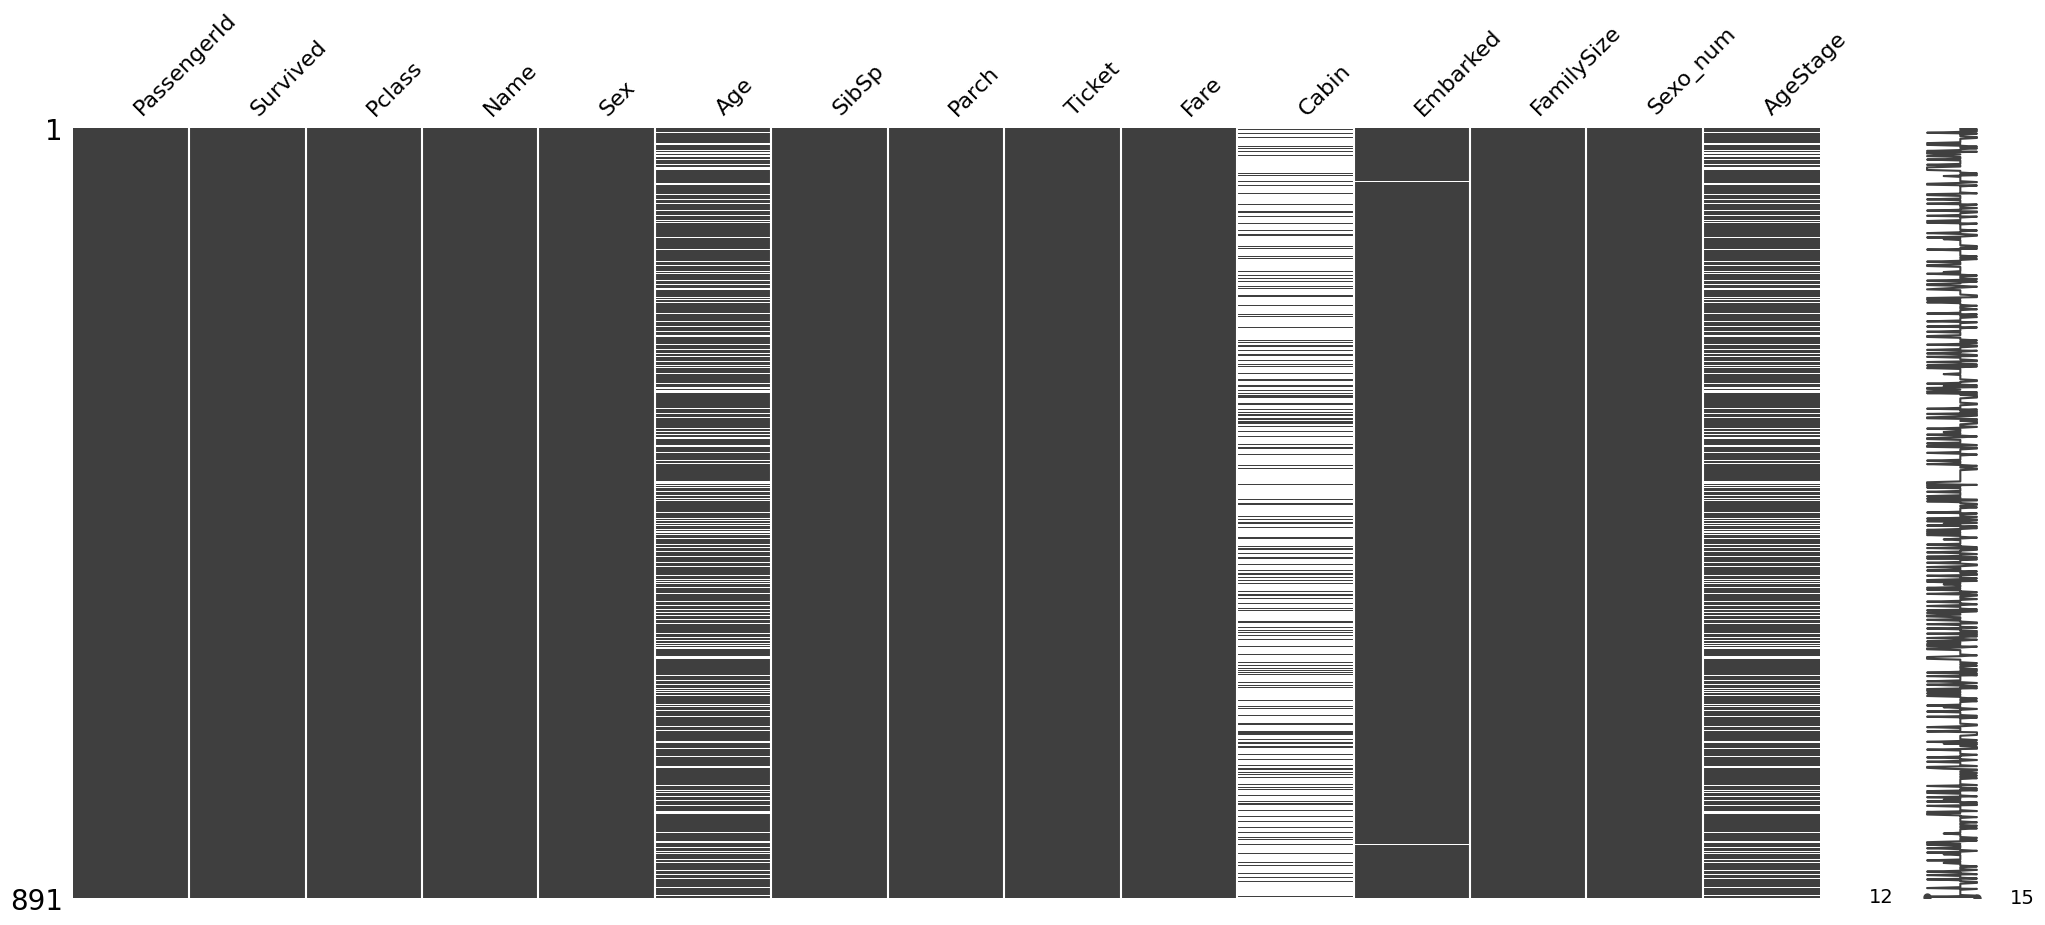

In [18]:
msno.matrix(titanic) #Lo mostramos de forma visual

In [19]:
tarifa_0 = titanic.query('Fare == 0') #Revisamos todos los pasajeros que tengan tarifa 0

print(tarifa_0['Pclass'].value_counts())
print(len(tarifa_0) / len(titanic) * 100)
print(tarifa_0)

Pclass
2    6
1    5
3    4
Name: count, dtype: int64
1.6835016835016834
     PassengerId  Survived  Pclass                              Name   Sex  \
179          180         0       3               Leonard, Mr. Lionel  male   
263          264         0       1             Harrison, Mr. William  male   
271          272         1       3      Tornquist, Mr. William Henry  male   
277          278         0       2       Parkes, Mr. Francis "Frank"  male   
302          303         0       3   Johnson, Mr. William Cahoone Jr  male   
413          414         0       2    Cunningham, Mr. Alfred Fleming  male   
466          467         0       2             Campbell, Mr. William  male   
481          482         0       2  Frost, Mr. Anthony Wood "Archie"  male   
597          598         0       3               Johnson, Mr. Alfred  male   
633          634         0       1     Parr, Mr. William Henry Marsh  male   
674          675         0       2        Watson, Mr. Ennis Hastings 

Pclass
3    136
1     30
2     11
Name: count, dtype: int64


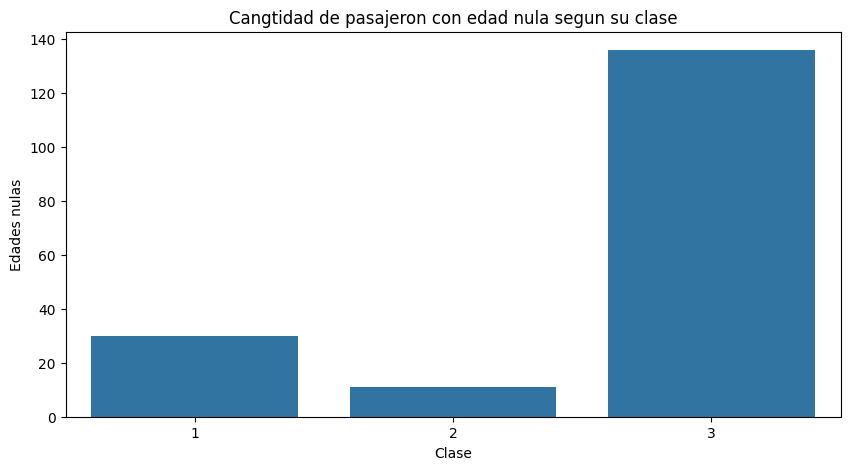

In [20]:
edad_nula = titanic[titanic['Age'].isnull()] #Creamos una variable donde almacenemos todos los valores nulos en edad
print(edad_nula['Pclass'].value_counts()) 

plt.figure(figsize=(10, 5))
sns.countplot(x='Pclass', data=edad_nula) #Mostramos un conteo de frecuencias
plt.title('Cangtidad de pasajeron con edad nula segun su clase')
plt.ylabel('Edades nulas')
plt.xlabel('Clase')
plt.show()

Age         0
AgeStage    0
dtype: int64


<Axes: >

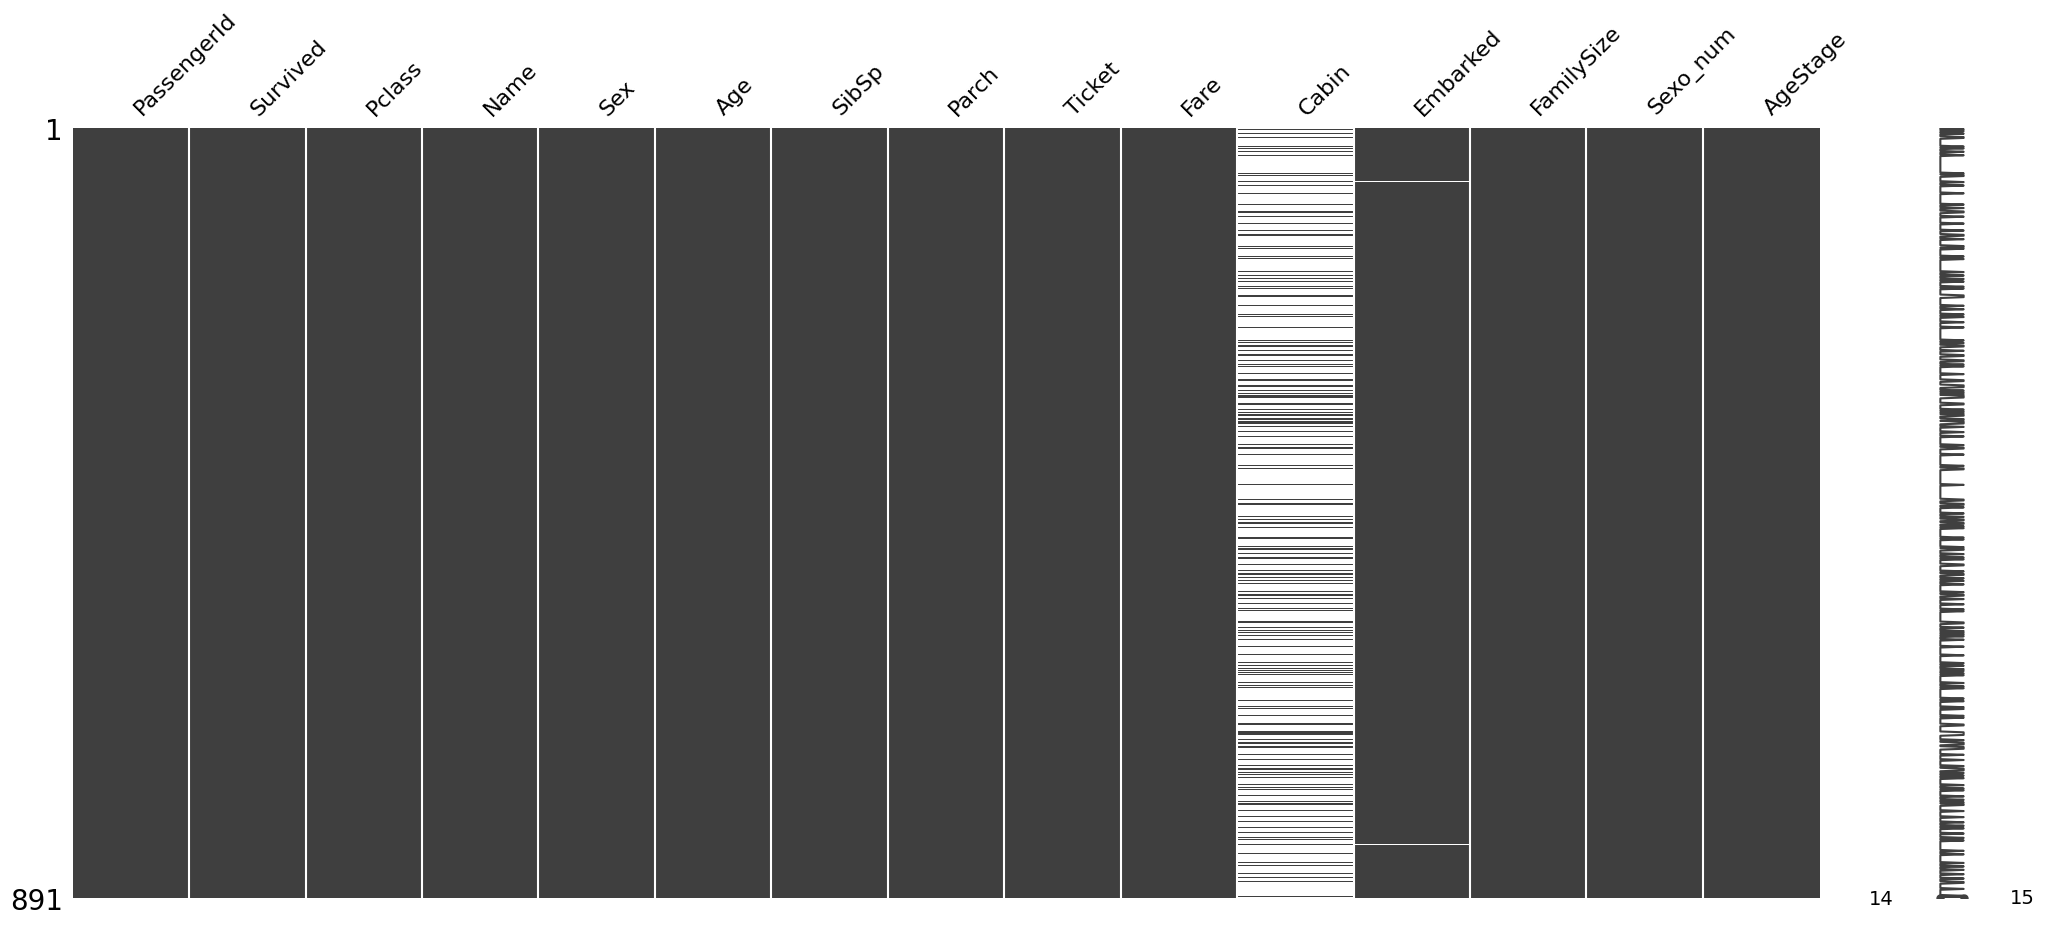

In [21]:
def rellenar_edad(titanic): #creamos una funcion para rellenar la variable edad
    return titanic['Age'].fillna(titanic.groupby(['Pclass', 'Sex'])['Age'].transform('median')) #Tomamos la mediana con base a la clase y el sexo para introudcirla en los valores nulos

titanic['Age'] = rellenar_edad(titanic) #Sobreescribimos edad
titanic['AgeStage'] = pd.cut(titanic['Age'], bins=[0, 12, 20, 30, 60, 100], labels=['Niño', 'Adolescente', 'Juventud', 'Adulto', 'Anciano']) #Sobreescribimos etapa de edad

print(titanic[['Age', 'AgeStage']].isnull().sum()) #Revisamos el proceso
msno.matrix(titanic) #Comprobamos graficamente

En esta sección se pudo encontrar que gran parte de los datos de edad y cabina no se encontraban dentro de la base de datos. Esto se puede atribuir a que gran parte de los pasajeros no eran figuras reconocidas y viajaban en tercera clase, por lo que para saber su información requerirían identificarlos o tener el registro del boletaje, el cual se perdió junto con el barco. Por lo que dejó a 136 pasajeros de tercera clase sin información sobre su edad, mucho menos su cabina. Aunque este fenómeno sea mayormente experimentado en tercera clase, también hay casos para la segunda y primera clase, lo cual nos indica la dificultad de verificar esta información en la época afectaba a todos. 

Una variable que también quería explorar, aunque no fuera nula, era la de tarifa, ya que había observado en el análisis inicial que su valor mínimo era 0, lo cual me parecía una incongruencia. Analizándolo, se encontró que 15 pasajeros están registrados con 0 dólares de tarifa, distribuidos bastante equitativamente entre las 3 clases. Haciendo una investigación más extensa, encontré que el único superviviente, Tornquist, Mr. William Henry, está registrado en la enciclopedia titánica con el boleto 370160 correspondiente a £7 5s. Sin embargo, este le fue regalado por la compañía en la que trabajaba por un fallo en el barco que tenía que tomar inicialmente, por lo que podría ser una posible explicación de la tarifa 0.

Finalmente, para poder solucionar la falta de valores, cree una función que tomara la mediana de la edad según el sexo y la clase para reemplazar los valores nulos. Se utilizó la mediana en este caso debido a la presencia de valores atípicos que podrían hacer que la media fuera imprecisa. Dado que para este análisis específico no estamos empleando la información de cabina y embarcación, opté por dejarlas en su estado original.

## Parte 4: Una Pregunta Propia

Pregunta clave: ¿Cuál es la suma de caracteristicas que mayor probabilidad te daban para sobrevivir al titanic en esa epoca?

In [22]:
def classify_family(FamilySize): #Creamos una función para lidiar con la clasificación de familia de mejor manera
    if FamilySize == 1: return 'Viaja Solo (1) '
    elif 2 <= FamilySize <= 3: return 'Familia Pequeña (2-3)'
    elif 4 <= FamilySize <= 5: return 'Familia Mediana (4-5)'
    else: return 'Familia Grande (5+)'
    
titanic['FamilyGroup'] = titanic['FamilySize'].apply(classify_family) #Creamos una nueva varibale

grouped = titanic.groupby(['Pclass', 'Sex', 'AgeStage', 'FamilyGroup'], observed=True)['Survived'].agg(['mean', 'count']) #Clasificamos relacionanado todas las variables de interes con su superviviencia, mostrando su media de supervivencia y el numero de personas

grupos_repre = grouped[grouped['count'] >= 8].sort_values(by='mean', ascending=False) #Sorteamos para eliminar todos los grupos menores a 7 personas paea evitar casos muy especificos

print("Numero de grupos representativos:")
print(len(grupos_repre)) #muestra el numero de grupos generados

print("\n10 mejores condiciones para sobrevivir")
print(grupos_repre.head(10)) 

print("\n10 peores condiciones para sobrevivir")
print(grupos_repre.tail(10))

Numero de grupos representativos:
32

10 mejores condiciones para sobrevivir
                                                     mean  count
Pclass Sex    AgeStage    FamilyGroup                           
1      female Adolescente Familia Pequeña (2-3)  1.000000      9
              Juventud    Viaja Solo (1)         1.000000     13
              Adulto      Familia Pequeña (2-3)  1.000000     38
2      male   Niño        Familia Pequeña (2-3)  1.000000      8
1      female Adulto      Viaja Solo (1)         0.944444     18
2      female Juventud    Viaja Solo (1)         0.923077     13
              Adulto      Familia Pequeña (2-3)  0.909091     11
                          Viaja Solo (1)         0.875000     16
              Juventud    Familia Pequeña (2-3)  0.833333     12
3      female Niño        Familia Pequeña (2-3)  0.666667      9

10 peores condiciones para sobrevivir
                                                   mean  count
Pclass Sex  AgeStage    FamilyGroup      

Notando los resultados, se pueden hacer varias observaciones cruciales a la pregunta clave. Inicialmente, vemos que existen 4 grupos representativos, los cuales tuvieron una supervivencia del 100 %. De estos 4, observamos que los 3 primeros tienen varias características en común, todas eran mujeres de primera clase con familias entre 1-3 integrantes de entre 12-60 años. Sin embargo, el 4.º grupo tiene la particularidad de tener una diferencia clave, el hecho de que sus miembros son niños del género masculino. En esta misma línea podemos notar que las mejores 10 condiciones son todas personas femeninas de primera y segunda clase, a excepción del previo mencionado caso de los niños varones y, en el número 10, niñas de tercera clase. Esto nos proporciona evidencia para el previamente mencionado efecto "Mujeres y niños primero", el cual parece reflejarse en esta situación. 

En contraste directo, podemos observar que las 10 peores condiciones son todas varones de segunda y tercera clase, con la única excepción en el octavo puesto en orden ascendente, los ancianos de primera clase. Esto nos ayuda a reforzar nuestras predicciones iniciales de que existió un favorecimiento para los pasajeros de primera clase y que los miembros de la tercera edad fueron los que menos sobrevivieron. 

## Reflexión final

Dentro del análisis, lo más complejo fue entender exactamente qué representaba cada variable y cómo las podía relacionar con las otras. También, qué gráficas utilizar para cada variable particular. Sin embargo, ambos problemas se resolvieron jugando con las posibilidades y leyendo literatura de análisis exploratorio. En general, el proceso me ayudó a entender cómo usar las diferentes librerías de ciencia de datos y entender cómo llevar a cabo el proceso para futuros análisis. 